In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [2]:
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Pandas: 3.0.5
NumPy: 2.5.2
Scikit-learn: 1.9.0


In [3]:
df = pd.read_csv("../data/AIDS_Classification.csv")

In [4]:
df.head()

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected
0,948,2,48,89.8128,0,0,0,100,0,0,...,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,...,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,...,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,...,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,...,1,3,0,0,0,504,353,870,782,0


In [5]:
df.shape

(2139, 23)

In [6]:
df.columns

Index(['time', 'trt', 'age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof',
       'oprior', 'z30', 'preanti', 'race', 'gender', 'str2', 'strat',
       'symptom', 'treat', 'offtrt', 'cd40', 'cd420', 'cd80', 'cd820',
       'infected'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time      2139 non-null   int64  
 1   trt       2139 non-null   int64  
 2   age       2139 non-null   int64  
 3   wtkg      2139 non-null   float64
 4   hemo      2139 non-null   int64  
 5   homo      2139 non-null   int64  
 6   drugs     2139 non-null   int64  
 7   karnof    2139 non-null   int64  
 8   oprior    2139 non-null   int64  
 9   z30       2139 non-null   int64  
 10  preanti   2139 non-null   int64  
 11  race      2139 non-null   int64  
 12  gender    2139 non-null   int64  
 13  str2      2139 non-null   int64  
 14  strat     2139 non-null   int64  
 15  symptom   2139 non-null   int64  
 16  treat     2139 non-null   int64  
 17  offtrt    2139 non-null   int64  
 18  cd40      2139 non-null   int64  
 19  cd420     2139 non-null   int64  
 20  cd80      2139 non-null   int64  
 21  cd

In [8]:
df.isnull().sum()

time        0
trt         0
age         0
wtkg        0
hemo        0
homo        0
drugs       0
karnof      0
oprior      0
z30         0
preanti     0
race        0
gender      0
str2        0
strat       0
symptom     0
treat       0
offtrt      0
cd40        0
cd420       0
cd80        0
cd820       0
infected    0
dtype: int64

In [9]:
df["infected"].value_counts()

infected
0    1618
1     521
Name: count, dtype: int64

In [10]:
df["infected"].value_counts(normalize=True) * 100

infected
0    75.642824
1    24.357176
Name: proportion, dtype: float64

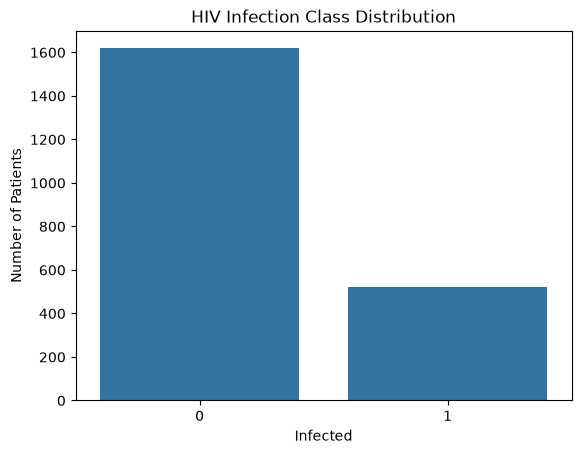

In [11]:
sns.countplot(data=df, x="infected")
plt.title("HIV Infection Class Distribution")
plt.xlabel("Infected")
plt.ylabel("Number of Patients")
plt.show()

In [12]:
x = df.drop("infected", axis=1)
y = df["infected"]

In [13]:
print("x shape:",x.shape)
print("y shape:", y.shape)

x shape: (2139, 22)
y shape: (2139,)


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (1711, 22)
Testing data: (428, 22)


In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
model = LogisticRegression(max_iter=1000)

In [19]:
model.fit(x_train,y_train)

c:\Users\user\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [20]:
y_pred = model.predict(x_test)

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8574766355140186


In [23]:
from sklearn.metrics import confusion_matrix

In [24]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[305  19]
 [ 42  62]]


In [25]:
from sklearn.metrics import classification_report

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       324
           1       0.77      0.60      0.67       104

    accuracy                           0.86       428
   macro avg       0.82      0.77      0.79       428
weighted avg       0.85      0.86      0.85       428



In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()

In [29]:
X=df.drop("infected", axis =1)
y=df["infected"]

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1711, 22)
(428, 22)
(1711,)
(428,)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [34]:
X_train_scaled = scaler.fit_transform(X_train)

In [35]:
X_test_scaled = scaler.transform(X_test)

In [36]:
print("Training scaled:", X_train_scaled.shape)
print("Testing scaled:", X_test_scaled.shape)

Training scaled: (1711, 22)
Testing scaled: (428, 22)


In [37]:
scaled_model= LogisticRegression(max_iter=1000)

In [38]:
scaled_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [39]:
y_pred_scaled = scaled_model.predict(X_test_scaled)

In [40]:
scaled_accuracy = accuracy_score(y_test, y_pred_scaled)
print("Scaled Logistic Regression Accuracy:", scaled_accuracy)

Scaled Logistic Regression Accuracy: 0.8598130841121495


In [41]:
print(classification_report(y_test, y_pred_scaled))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       324
           1       0.77      0.61      0.68       104

    accuracy                           0.86       428
   macro avg       0.82      0.77      0.79       428
weighted avg       0.85      0.86      0.85       428



In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [44]:
rf_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [45]:
rf_pred = rf_model.predict(X_test)

In [46]:
rf_accuracy = accuracy_score(y_test, rf_pred)

In [47]:
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8901869158878505


In [48]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93       324
           1       0.81      0.72      0.76       104

    accuracy                           0.89       428
   macro avg       0.86      0.83      0.85       428
weighted avg       0.89      0.89      0.89       428



In [49]:
rf_cm = confusion_matrix(y_test, rf_pred)

In [50]:
print(rf_cm)

[[306  18]
 [ 29  75]]


In [51]:
rf_train_pred = rf_model.predict(X_train)

In [52]:
rf_train_accuracy = accuracy_score(y_train, rf_train_pred)

In [53]:
print("Testing Accuracy:", rf_train_accuracy)

Testing Accuracy: 1.0


In [54]:
print("Testing Accuracy:", rf_accuracy)

Testing Accuracy: 0.8901869158878505


In [55]:
rf_model_depth = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [56]:
rf_model_depth.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [57]:
rf_depth_train_pred = rf_model_depth.predict(X_train)

In [58]:
rf_depth_test_pred = rf_model_depth.predict(X_test)

In [59]:
rf_depth_train_accuracy = accuracy_score(
    y_train,
    rf_depth_train_pred
)

rf_depth_test_accuracy = accuracy_score(
    y_test,
    rf_depth_test_pred
)

print("Training Accuracy:", rf_depth_train_accuracy)
print("Testing Accuracy:", rf_depth_test_accuracy)

Training Accuracy: 0.896551724137931
Testing Accuracy: 0.8621495327102804


In [60]:
from sklearn.model_selection import cross_val_score

In [61]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

In [62]:
print("Cross-validation scores:", cv_scores)

Cross-validation scores: [0.86880466 0.89181287 0.87426901 0.89181287 0.9122807 ]


In [63]:
print("Mean CV accuracy:", cv_scores.mean())

Mean CV accuracy: 0.8877960206639047


In [64]:
depths = [5,10,15,20]
for depth in depths:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv = 5,
        scoring="accuracy"
    )
    
    print("Depth:", depth)
    print("Mean CV accuracy:", scores.mean())
    print()

Depth: 5
Mean CV accuracy: 0.8655772083269397

Depth: 10
Mean CV accuracy: 0.8860433396416211

Depth: 15
Mean CV accuracy: 0.8813683869537791

Depth: 20
Mean CV accuracy: 0.8877960206639047



In [65]:
rf_best = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

In [66]:
rf_best.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [67]:
rf_best_pred = rf_best.predict(X_test)

In [68]:
rf_best_accuracy = accuracy_score(y_test, rf_best_pred)
print("Final Random Forest Accuracy:", rf_best_accuracy)

Final Random Forest Accuracy: 0.8901869158878505


In [69]:
print(classification_report(y_test, rf_best_pred))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93       324
           1       0.81      0.72      0.76       104

    accuracy                           0.89       428
   macro avg       0.86      0.83      0.85       428
weighted avg       0.89      0.89      0.89       428



In [70]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_best.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

    Feature  Importance
0      time    0.375162
19    cd420    0.134406
18     cd40    0.066725
20     cd80    0.055737
3      wtkg    0.054822
21    cd820    0.052271
2       age    0.050573
10  preanti    0.046578
17   offtrt    0.043065
1       trt    0.019257
7    karnof    0.015269
11     race    0.010751
14    strat    0.010711
15  symptom    0.010093
5      homo    0.010073
16    treat    0.007911
12   gender    0.007460
9       z30    0.007031
4      hemo    0.006987
6     drugs    0.006501
13     str2    0.005778
8    oprior    0.002839


In [71]:
print(df.columns.tolist())

['time', 'trt', 'age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'str2', 'strat', 'symptom', 'treat', 'offtrt', 'cd40', 'cd420', 'cd80', 'cd820', 'infected']


In [72]:
print(df.dtypes)

time          int64
trt           int64
age           int64
wtkg        float64
hemo          int64
homo          int64
drugs         int64
karnof        int64
oprior        int64
z30           int64
preanti       int64
race          int64
gender        int64
str2          int64
strat         int64
symptom       int64
treat         int64
offtrt        int64
cd40          int64
cd420         int64
cd80          int64
cd820         int64
infected      int64
dtype: object


In [73]:
print(df.describe())

              time          trt          age         wtkg         hemo  \
count  2139.000000  2139.000000  2139.000000  2139.000000  2139.000000   
mean    879.098177     1.520804    35.248247    75.125311     0.084151   
std     292.274324     1.127890     8.709026    13.263164     0.277680   
min      14.000000     0.000000    12.000000    31.000000     0.000000   
25%     727.000000     1.000000    29.000000    66.679200     0.000000   
50%     997.000000     2.000000    34.000000    74.390400     0.000000   
75%    1091.000000     3.000000    40.000000    82.555200     0.000000   
max    1231.000000     3.000000    70.000000   159.939360     1.000000   

              homo        drugs       karnof       oprior          z30  ...  \
count  2139.000000  2139.000000  2139.000000  2139.000000  2139.000000  ...   
mean      0.661057     0.131370    95.446470     0.021973     0.550257  ...   
std       0.473461     0.337883     5.900985     0.146629     0.497584  ...   
min       0.00000

In [74]:
print(df["infected"].value_counts())

infected
0    1618
1     521
Name: count, dtype: int64


In [75]:
df["infected"].value_counts(normalize=True) * 100

infected
0    75.642824
1    24.357176
Name: proportion, dtype: float64

In [76]:
from sklearn.model_selection import cross_val_score



In [77]:
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv = 5
)

print(scores)
print("Average:", scores.mean())

[0.86880466 0.89181287 0.87426901 0.89181287 0.9122807 ]
Average: 0.8877960206639047


In [78]:
%whos

Variable                  Type                      Data/Info
-------------------------------------------------------------
LogisticRegression        type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier    ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler            type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                         DataFrame                 Shape: (2139, 22)
X_test                    DataFrame                 Shape: (428, 22)
X_test_scaled             ndarray                   428x22: 9416 elems, type `float64`, 75328 bytes
X_train                   DataFrame                 Shape: (1711, 22)
X_train_scaled            ndarray                   1711x22: 37642 elems, type `float64`, 301136 bytes (294.078125 kb)
accuracy                  float                     0.8574766355140186
accuracy_score            function                  <

In [79]:
%history -n -g "LogisticRegression"
%history -n -g "RandomForestClassifier"

11/17: from sklearn.linear_model import LogisticRegression
11/18: model = LogisticRegression(max_item=1000)
11/19: model = LogisticRegression(max_iter=1000)
12/17: from sklearn.linear_model import LogisticRegression
12/18: model = LogisticRegression(max_iter=1000)
13/17: from sklearn.linear_model import LogisticRegression
13/18: model = LogisticRegression(max_iter=1000)
14/17: from sklearn.linear_model import LogisticRegression
14/18: model = LogisticRegression(max_iter=1000)
14/43: from sklearn.linear_model import LogisticRegression
14/44: model = LogisticRegression(max_iter=1000)
14/72: from sklearn.linear_model import LogisticRegression
14/73: model = LogisticRegression(max_iter=1000)
14/85: scaled_model = LogisticRegression(max_iter=1000)
14/104: from sklearn.linear_model import LogisticRegression
14/105: model = LogisticRegression(max_iter=1000)
14/117: scaled_model = LogisticRegression(max_iter=1000)
14/138: from sklearn.linear_model import LogisticRegression
14/139: model = Logi

In [80]:
%history -n -g "RandomForestClassifier"

14/272:
from sklearn.ensemble import RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
14/273: from sklearn.ensemble import RandomForestClassifier
14/274:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
16/42: from sklearn.ensemble import RandomForestClassifier
16/43:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
17/42: from sklearn.ensemble import RandomForestClassifier
17/43:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
18/42: from sklearn.ensemble import RandomForestClassifier
18/43:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
19/42: from sklearn.ensemble import RandomForestClassifier
19/43:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
20/42: from sklearn.ensemble import RandomForestClassifier
20/43:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
22/42: from sklearn.ens

In [81]:
scores_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv = 5
)
print(scores_rf)
print("Average:", scores_rf.mean())

[0.86880466 0.89181287 0.87426901 0.89181287 0.9122807 ]
Average: 0.8877960206639047


In [82]:
from sklearn.pipeline import make_pipeline
lr_scaled_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)
scores_lr_scaled = cross_val_score(
    lr_scaled_model,
    X_train,
    y_train,
    cv=5
)
print("Logistic Regression")
print("Fold scores:", scores_lr_scaled)
print("Mean CV accuracy:", scores_lr_scaled.mean())

Logistic Regression
Fold scores: [0.86588921 0.85964912 0.86842105 0.85964912 0.87134503]
Mean CV accuracy: 0.8649907080626738


In [83]:
rf_depth5 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [84]:
scores_rf_depth5 = cross_val_score(
    rf_depth5,
    X_train,
    y_train,
    cv=5
)

print("Random Forest - max_depth=5")
print("Fold scores:", scores_rf_depth5)
print("Mean CV Accuracy:", scores_rf_depth5.mean())

Random Forest - max_depth=5
Fold scores: [0.86297376 0.85964912 0.85380117 0.88596491 0.86549708]
Mean CV Accuracy: 0.8655772083269397


In [85]:
rf_depth20 = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

scores_rf_depth20 = cross_val_score(
    rf_depth20,
    X_train,
    y_train,
    cv=5
)

print("Random Forest - max_depth=20")
print("Fold scores:", scores_rf_depth20)
print("Mean CV Accuracy:", scores_rf_depth20.mean())

Random Forest - max_depth=20
Fold scores: [0.86880466 0.89181287 0.87426901 0.89181287 0.9122807 ]
Mean CV Accuracy: 0.8877960206639047


In [86]:
rf_depth20.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [87]:
y_pred_rf = rf_depth20.predict(X_test)

In [88]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8901869158878505

Confusion Matrix:
[[306  18]
 [ 29  75]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       324
           1       0.81      0.72      0.76       104

    accuracy                           0.89       428
   macro avg       0.86      0.83      0.85       428
weighted avg       0.89      0.89      0.89       428



In [89]:
y_prob_rf = rf_depth20.predict_proba(X_test)[:,1]

In [90]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9208066239316239


In [91]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_depth20.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

    Feature  Importance
0      time    0.375162
19    cd420    0.134406
18     cd40    0.066725
20     cd80    0.055737
3      wtkg    0.054822
21    cd820    0.052271
2       age    0.050573
10  preanti    0.046578
17   offtrt    0.043065
1       trt    0.019257
7    karnof    0.015269
11     race    0.010751
14    strat    0.010711
15  symptom    0.010093
5      homo    0.010073
16    treat    0.007911
12   gender    0.007460
9       z30    0.007031
4      hemo    0.006987
6     drugs    0.006501
13     str2    0.005778
8    oprior    0.002839


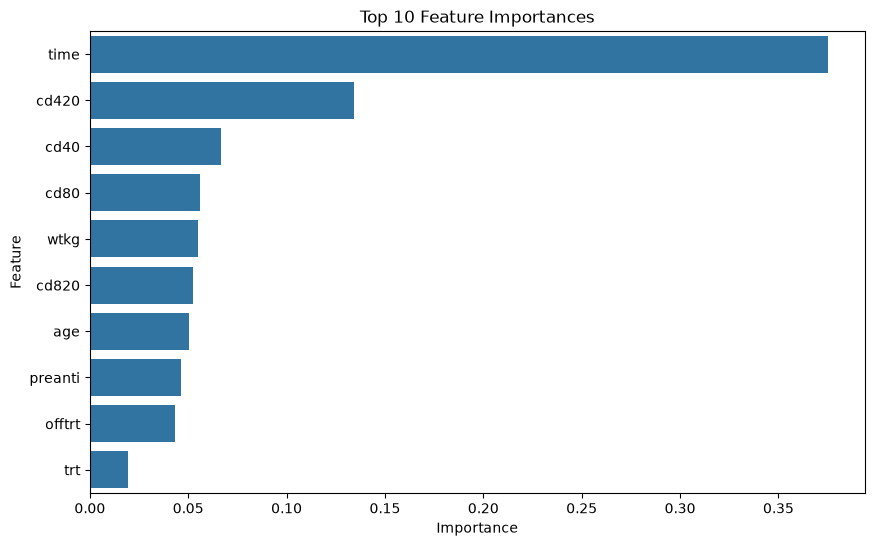

In [92]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.show()

In [93]:
from sklearn.model_selection import GridSearchCV

In [94]:
rf = RandomForestClassifier(
    random_state=42
)

In [95]:
param_grid={
    "n_estimators": [100, 200],
    "max_depth": [10,20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]    
}

In [96]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [97]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ve

In [98]:
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest CV Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best CV Accuracy:
0.8907182923294631


In [99]:
grid_search.best_estimator_

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [100]:
best_rf = grid_search.best_estimator_

In [101]:
y_pred_best= best_rf.predict(X_test)

In [102]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_best = accuracy_score(y_test, y_pred_best)

print("Final Test Accuracy:", accuracy_best)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


Final Test Accuracy: 0.897196261682243

Confusion Matrix:
[[307  17]
 [ 27  77]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       324
           1       0.82      0.74      0.78       104

    accuracy                           0.90       428
   macro avg       0.87      0.84      0.86       428
weighted avg       0.89      0.90      0.90       428



In [103]:
y_prob_best= best_rf.predict_proba(X_test)[:,1]

In [104]:
from sklearn.metrics import roc_auc_score
roc_auc_best = roc_auc_score(y_test, y_prob_best)
print("Tuned Random Forest ROC-AUC:", roc_auc_best)

Tuned Random Forest ROC-AUC: 0.924471747388414


In [105]:
y_prob_best = best_rf.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_auc_score
roc_auc_best = roc_auc_score(y_test, y_prob_best)
print("Tuned Random Forest ROC-AUC:", roc_auc_best)

Tuned Random Forest ROC-AUC: 0.924471747388414


In [106]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(best_rf, "../models/hiv_rf_model.joblib")
print("Model saved successfully!")

Model saved successfully!


In [107]:
import os
print(os.path.exists("../models/hiv_rf_model.joblib"))

True
